# Lekcja 1 — QAM + AWGN

## Cel nauki
| Pojęcie | Co to jest | Rola w pipeline |
|---------|-----------|-----------------|
| **Bits** | 0/1 | Informacja źródłowa |
| **Mapper** | bits → symbole zespolone | Modulacja |
| **Konstelacja** | punkty w płaszczyźnie I/Q | Alfabet modulacji |
| **AWGN** | $y = x + n$ | Najprostszy kanał |
| **Demapper** | symbole → LLR | Soft detection |
| **BER** | odsetek błędnych bitów | Metryka jakości |

## Rzędy QAM w tej lekcji
| bity/symbol | Nazwa | Punktów w konstelacji |
|-------------|-------|----------------------|
| 2 | QPSK | 4 |
| 4 | 16-QAM | 16 |
| 6 | 64-QAM | 64 |
| 8 | 256-QAM | 256 |
| 10 | 1024-QAM | 1024 |

## Co zostanie zastąpione przez sieć?
W tej lekcji **nic** — to fundament. Sieć neuronowa w lekcji 7 zastąpi demapper (i wcześniejsze bloki OFDM), ale **LLR → LDPC** zostaje klasyczne.

## Równanie kanału
$$ y = x + n, \quad n \sim \mathcal{CN}(0, \sigma^2) $$


In [1]:
import sys
from pathlib import Path

# Dodaj src/ do PYTHONPATH
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch

try:
    import sionna as sn
    import sionna.phy
except ImportError as e:
    raise ImportError(
        "Brak Sionny. Uruchom z katalogu magisterka/: ./scripts/drun sync"
    ) from e

from src.utils.setup import print_environment, get_device

sn.phy.config.seed = 42
device = get_device()
print_environment()


=== Środowisko neural-receiver ===
Sionna:  2.0.1
PyTorch: 2.13.0+cu129
CUDA:    True
Device:  cuda
GPU:     NVIDIA GeForce GTX 1660 SUPER


## Krok 1 — Źródło bitów (przykład: QPSK)

In [2]:
NUM_BITS_PER_SYMBOL = 2  # zaczynamy od QPSK
BATCH_SIZE = 1000
BLOCK_LENGTH = 10240  # dzielne przez 10 (max QAM w lekcji)

binary_source = sn.phy.mapping.BinarySource()
bits = binary_source([BATCH_SIZE, BLOCK_LENGTH])

print("Shape bits:", bits.shape)       # [batch, block_length]
print("Typ:", bits.dtype)
print("Przykład (pierwsze 8 bitów):", bits[0, :8].tolist())


Shape bits: torch.Size([1000, 10240])
Typ: torch.float32
Przykład (pierwsze 8 bitów): [0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0]


## Krok 2 — Wszystkie konstelacje QAM (QPSK → 1024-QAM)

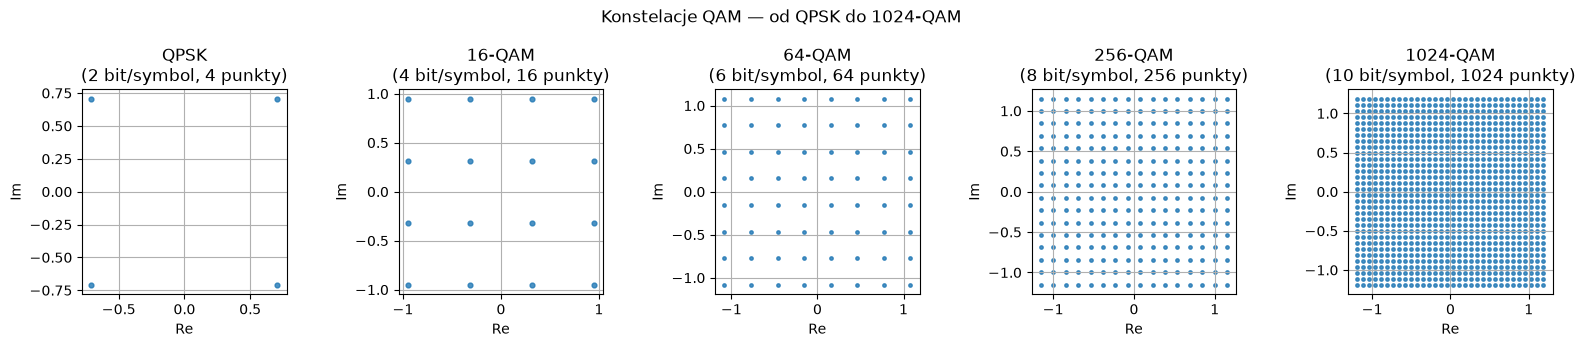

In [3]:
QAM_ORDERS = [2, 4, 6, 8, 10]
QAM_NAMES = {
    2: "QPSK",
    4: "16-QAM",
    6: "64-QAM",
    8: "256-QAM",
    10: "1024-QAM",
}

fig, axes = plt.subplots(1, len(QAM_ORDERS), figsize=(3.2 * len(QAM_ORDERS), 3.2))
if len(QAM_ORDERS) == 1:
    axes = [axes]

for ax, bps in zip(axes, QAM_ORDERS):
    constellation = sn.phy.mapping.Constellation("qam", bps)
    pts = constellation.points.detach().cpu().numpy()
    ax.scatter(pts.real, pts.imag, s=12 if bps <= 4 else 6, alpha=0.8)
    ax.set_aspect("equal")
    ax.grid(True, which="both")
    ax.set_xlabel("Re")
    ax.set_ylabel("Im")
    ax.set_title(f"{QAM_NAMES[bps]}\n({bps} bit/symbol, {2**bps} punkty)")

plt.suptitle("Konstelacje QAM — od QPSK do 1024-QAM", y=1.02)
plt.tight_layout()
plt.show()


## Krok 3 — Mapper (QPSK) i symbole TX

In [4]:
constellation = sn.phy.mapping.Constellation("qam", NUM_BITS_PER_SYMBOL)
mapper = sn.phy.mapping.Mapper(constellation=constellation)
assert BLOCK_LENGTH % NUM_BITS_PER_SYMBOL == 0

x = mapper(bits)
print("Shape x (symbole TX):", x.shape)  # [batch, num_symbols]
print("Przykład symbolu:", x[0, 0])


Shape x (symbole TX): torch.Size([1000, 5120])
Przykład symbolu: tensor(0.7071+0.7071j, device='cuda:0')


## Krok 4 — AWGN: konstelacje odebrane dla każdego rzędu QAM

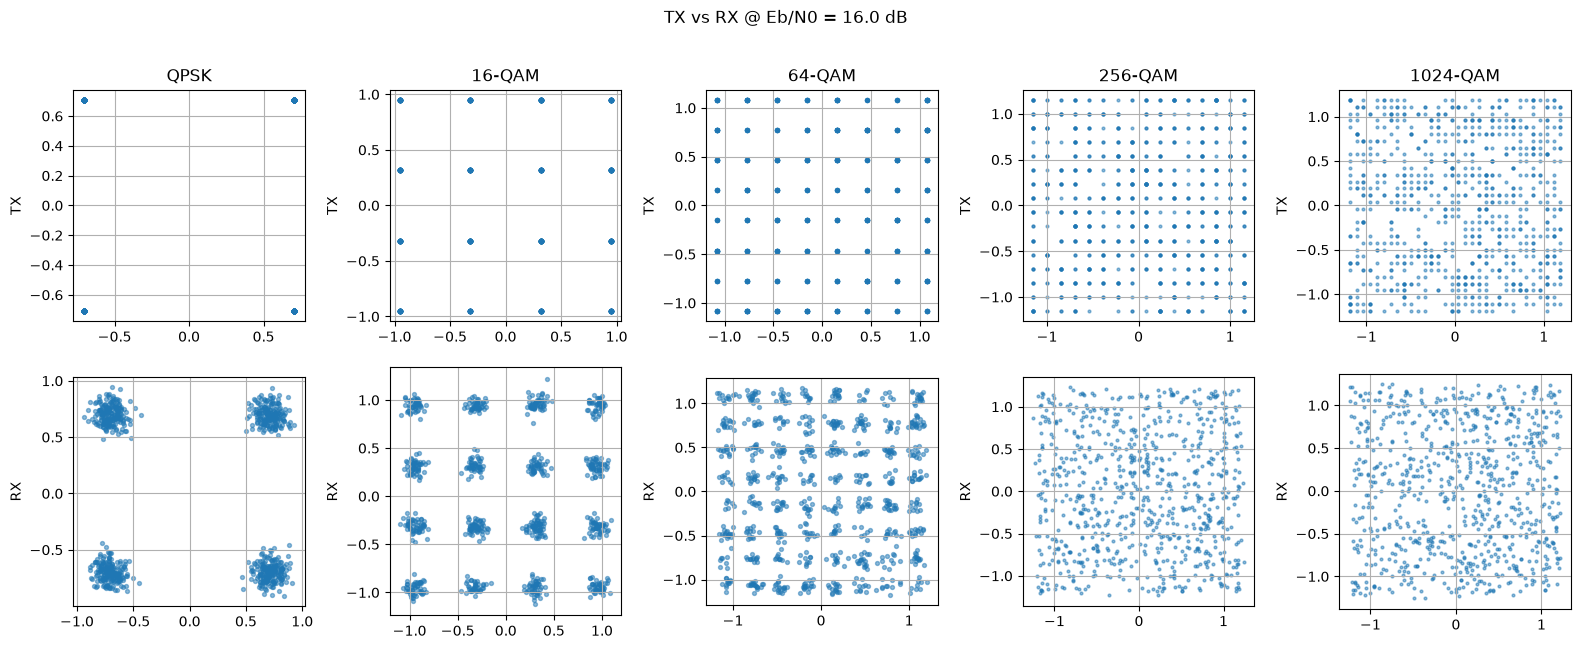

In [5]:
awgn = sn.phy.channel.AWGN()
EBN0_DB = 16.0  # wyższe SNR — 1024-QAM też coś widać
N_SCATTER = 800

fig, axes = plt.subplots(2, len(QAM_ORDERS), figsize=(3.2 * len(QAM_ORDERS), 6.4))
if len(QAM_ORDERS) == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for col, bps in enumerate(QAM_ORDERS):
    c = sn.phy.mapping.Constellation("qam", bps)
    m = sn.phy.mapping.Mapper(constellation=c)
    no = sn.phy.utils.ebnodb2no(EBN0_DB, bps, 1.0)

    n_bits = N_SCATTER * bps
    b = binary_source([1, n_bits])
    x_sym = m(b)[0]
    y_sym = awgn(x_sym.unsqueeze(0), no)[0]

    pts_tx = x_sym.detach().cpu().numpy()
    pts_rx = y_sym.detach().cpu().numpy()

    for row, (pts, label) in enumerate([(pts_tx, "TX"), (pts_rx, "RX")]):
        ax = axes[row, col]
        ax.scatter(pts.real, pts.imag, s=8 if bps <= 6 else 4, alpha=0.5)
        ax.set_aspect("equal")
        ax.grid(True, which="both")
        if row == 0:
            ax.set_title(QAM_NAMES[bps])
        ax.set_ylabel(label)

plt.suptitle(f"TX vs RX @ Eb/N0 = {EBN0_DB} dB", y=1.01)
plt.tight_layout()
plt.show()


## Krok 5 — Demapper → LLR → hard bits (QPSK)

In [6]:
no_qpsk = sn.phy.utils.ebnodb2no(EBN0_DB, NUM_BITS_PER_SYMBOL, 1.0)
y = awgn(x, no_qpsk)

demapper = sn.phy.mapping.Demapper("app", constellation=constellation)
llr = demapper(y, no_qpsk)

print("Shape LLR:", llr.shape)
print("LLR > 0 → bit=1, LLR < 0 → bit=0")
bits_hat = (llr > 0).float()

from src.utils.metrics import ber
print(f"BER QPSK @ {EBN0_DB} dB:", ber(bits, bits_hat))


Shape LLR: torch.Size([1000, 10240])
LLR > 0 → bit=1, LLR < 0 → bit=0
BER QPSK @ 16.0 dB: 0.0


## Krok 6 — Krzywe BER vs SNR (wszystkie rzędy QAM)

**Uncoded** = bity idą **prosto** z mappera przez kanał do demappera — **bez** kodu korekcji błędów (FEC).
W lekcji 5 dodamy **LDPC 5G** — wtedy nadajemy bity **z redundancją**, a odbiornik naprawia błędy transmisji.

To nie jest „szyfrowanie” ani Hamming w praktyce 5G — to **Forward Error Correction (FEC)**:
np. z 512 bitów informacji robisz 1024-bitowe słowo kodowe (rate ½), nadajesz je wszystkie,
a dekoder LDPC z LLR odzyskuje oryginalne bity nawet przy złym kanale.


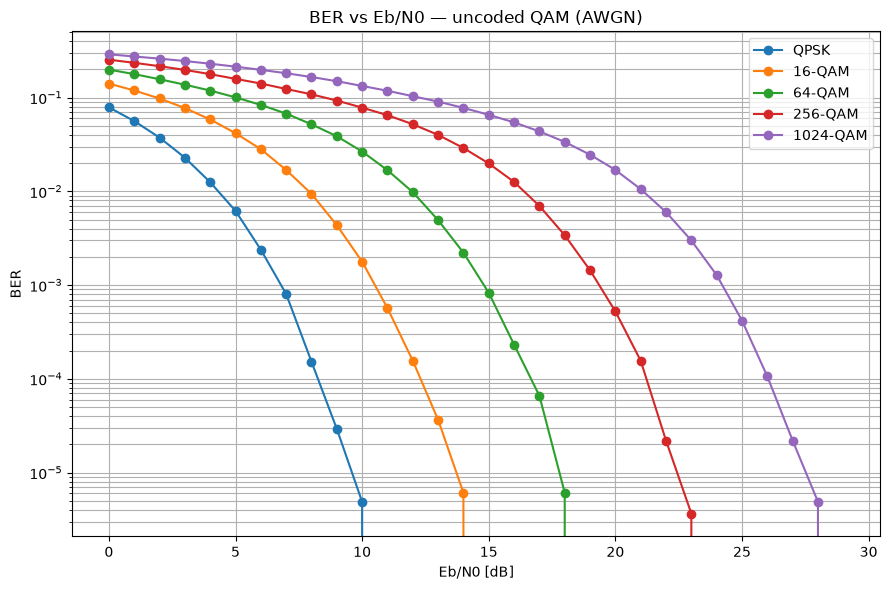

In [7]:
snr_range = np.arange(0, 30, 1)  # 0 … 30 dB
plt.figure(figsize=(9, 6))

for bps in QAM_ORDERS:
    c = sn.phy.mapping.Constellation("qam", bps)
    m = sn.phy.mapping.Mapper(constellation=c)
    d = sn.phy.mapping.Demapper("app", constellation=c)
    ber_vals = []

    block = 4096 - (4096 % bps)  # długość podzielna przez bps

    for ebno_db in snr_range:
        no = sn.phy.utils.ebnodb2no(ebno_db, bps, 1.0)
        b = binary_source([200, block])
        x_b = m(b)
        y_b = awgn(x_b, no)
        llr_b = d(y_b, no)
        ber_vals.append(ber(b, (llr_b > 0).float()))

    plt.semilogy(snr_range, ber_vals, "o-", label=QAM_NAMES[bps])

plt.xlabel("Eb/N0 [dB]")
plt.ylabel("BER")
plt.grid(True, which="both")
plt.legend()
plt.title("BER vs Eb/N0 — uncoded QAM (AWGN)")
plt.tight_layout()
plt.show()


## Podsumowanie
- Wyższy rząd QAM = **więcej bitów na symbol**, gęstsza konstelacja, **wyższe wymagania SNR**
- **Tensor bits**: `[batch, block_length]`
- **Tensor x**: `[batch, num_symbols]` — liczby zespolone
- **LLR** to logit dla każdego bitu — sieć neuronowa w lekcji 7 też produkuje LLR

## Ćwiczenie
Przy `Eb/N0 = 10 dB`: który rząd QAM ma BER < 1e-3? A który > 1e-1?

**Następna lekcja:** `02_ofdm_basics.ipynb`
